In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = {
    'Strategy': ['Base Prompt', 'Base Prompt', 'Base Prompt',
                 'Persona', 'Persona', 'Persona',
                 'Exemplars', 'Exemplars', 'Exemplars',
                 'Retcon', 'Retcon', 'Retcon',
                 'RetconPos', 'RetconPos', 'RetconPos'],
    'Temp': [0.0, 0.7, 1.0,
             0.0, 0.7, 1.0,
             0.0, 0.7, 1.0,
             0.0, 0.7, 1.0,
             0.0, 0.7, 1.0],
    'Flesch-Douma': [89.51, 88.59, 88.16,
                     89.33, 88.45, 87.53,
                     91.73, 91.93, 91.80,
                     91.93, 92.48, 92.62,
                     92.33, 92.49, 92.83],
    'BERTScore': [0.667, 0.667, 0.670,
                  0.665, 0.665, 0.664,
                  0.662, 0.663, 0.664,
                  0.660, 0.658, 0.655,
                  0.661, 0.661, 0.658],
    'Harmonic_Mean': [97.68, 97.16, 96.92,
                      97.58, 97.08, 96.56,
                      98.90, 99.01, 98.94,
                      99.01, 99.31, 99.38,
                      99.23, 99.31, 99.50]
}

df = pd.DataFrame(data)

df['Label'] = df['Strategy'] + ' ' + df['Temp'].astype(str)

strategy_colors = {
    'Base Prompt': '#E74C3C',
    'Persona': '#2ECC71',
    'Exemplars': '#3498DB',
    'Retcon': '#F39C12',
    'RetconPos': '#FFD700'
}

strategies = df['Strategy'].unique()

colors = [strategy_colors[strategy] for strategy in strategies]

print("\nColor mapping:")
for strategy, color in strategy_colors.items():
    print(f"  {strategy}: {color}")


Color mapping:
  Base Prompt: #E74C3C
  Persona: #2ECC71
  Exemplars: #3498DB
  Retcon: #F39C12
  RetconPos: #FFD700


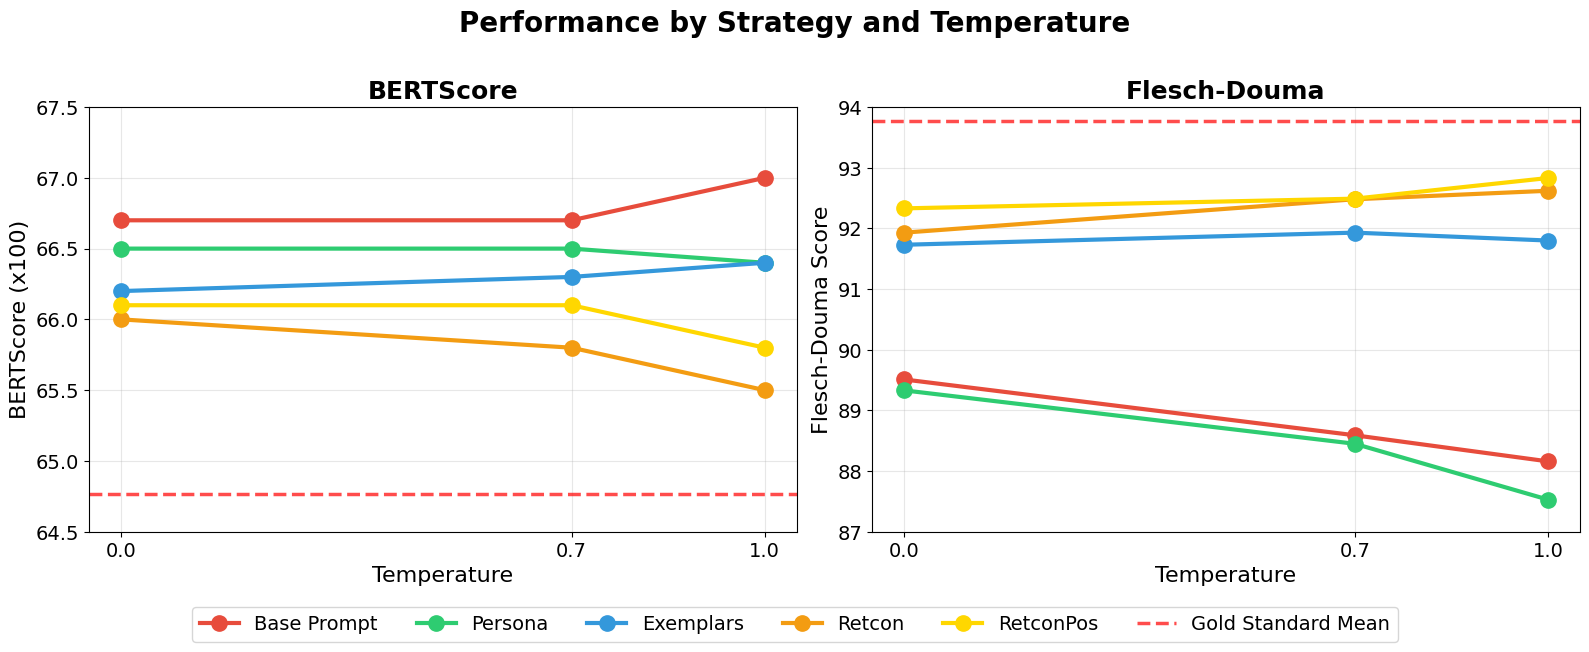

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i, strategy in enumerate(strategies):
    subset = df[df['Strategy'] == strategy].sort_values('Temp')
    
    ax1.plot(subset['Temp'], subset['BERTScore'] * 100,
             marker='o',
             markersize=11,
             linewidth=3,
             label=strategy,
             color=strategy_colors[strategy])
    
    ax2.plot(subset['Temp'], subset['Flesch-Douma'], 
             marker='o',
             markersize=11,
             linewidth=3,
             label=strategy,
             color=strategy_colors[strategy])

ax1.axhline(y=64.77, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Gold Standard Mean')
ax1.set_xlabel('Temperature', fontsize=16)
ax1.set_ylabel('BERTScore (x100)', fontsize=16)
ax1.set_title('BERTScore', fontsize=18, fontweight='bold')
ax1.set_xticks([0.0, 0.7, 1.0])
ax1.set_ylim(64.5, 67.5)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', labelsize=14)

ax2.axhline(y=93.77, color='red', linestyle='--', linewidth=2.5, alpha=0.7, label='Gold Standard Mean')
ax2.set_xlabel('Temperature', fontsize=16)
ax2.set_ylabel('Flesch-Douma Score', fontsize=16)
ax2.set_title('Flesch-Douma', fontsize=18, fontweight='bold')
ax2.set_xticks([0.0, 0.7, 1.0])
ax2.set_ylim(87, 94)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', labelsize=14)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05),
           fontsize=14,
           ncol=len(strategies) + 1)

plt.suptitle('Performance by Strategy and Temperature', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

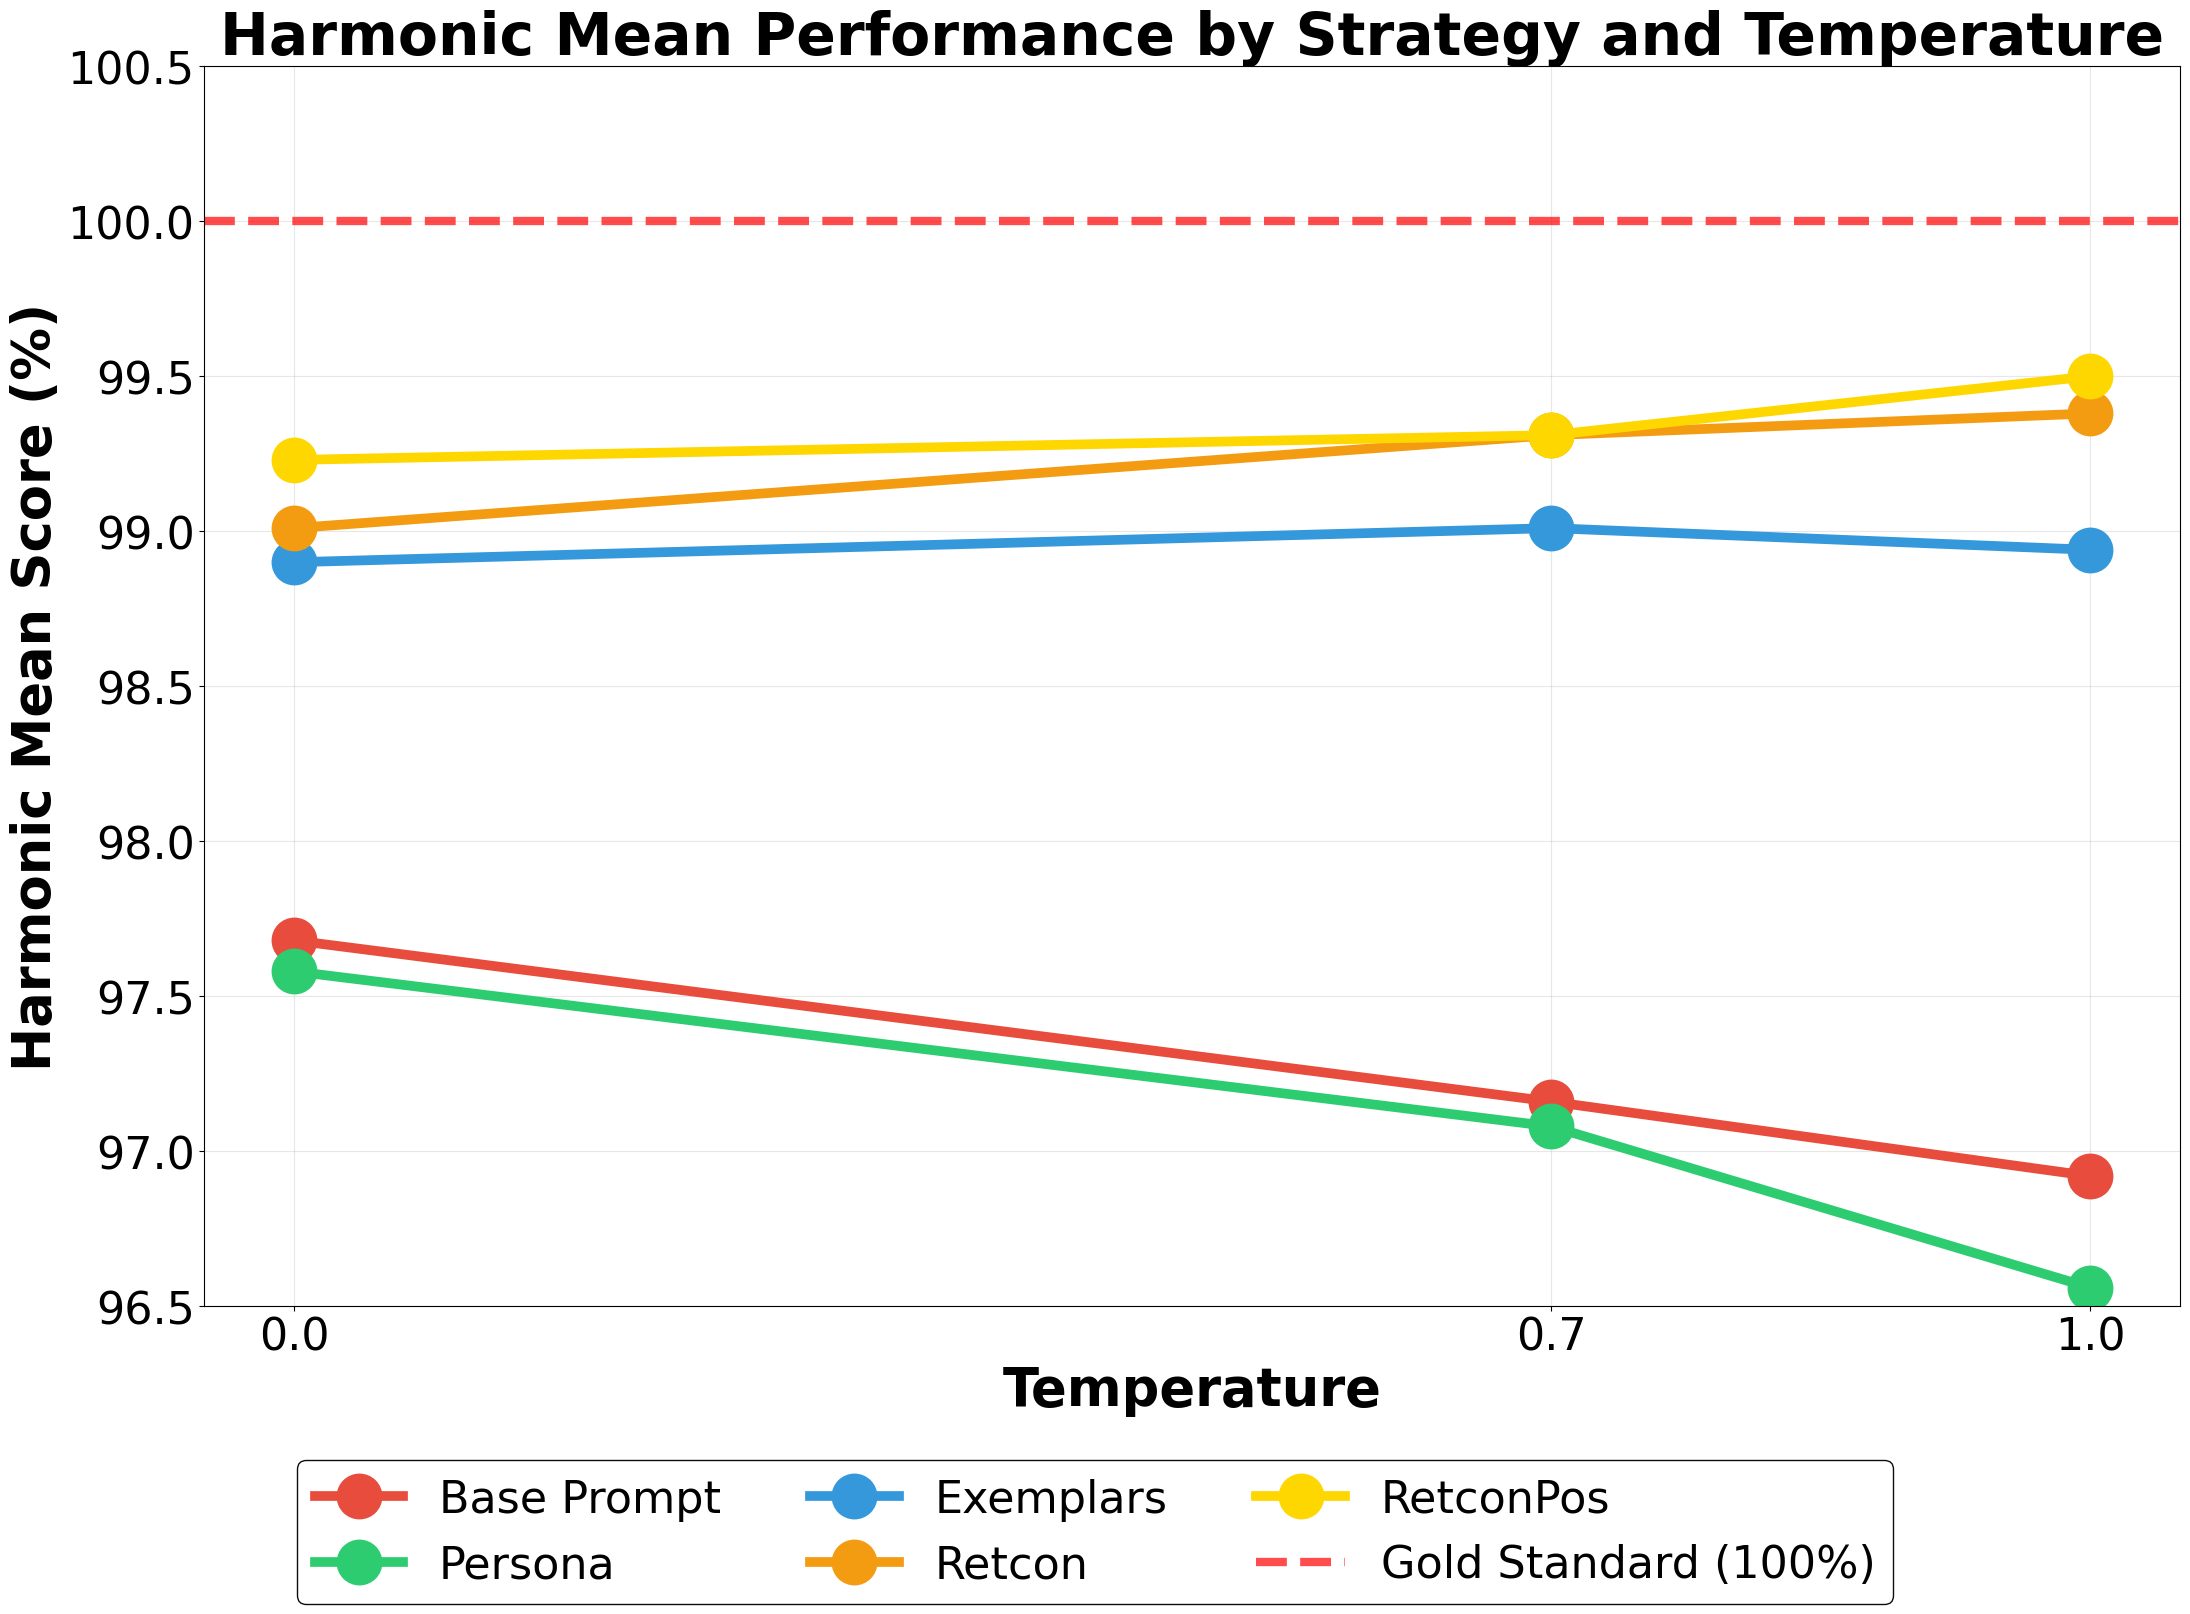

In [38]:
fig, ax = plt.subplots(figsize=(22, 16))

for i, strategy in enumerate(strategies):
    subset = df[df['Strategy'] == strategy].sort_values('Temp')
    
    ax.plot(subset['Temp'], subset['Harmonic_Mean'], 
            marker='o',
            markersize=32,
            linewidth=7,
            label=strategy,
            color=strategy_colors[strategy])

ax.axhline(y=100, color='red', linestyle='--', linewidth=6,
           label='Gold Standard (100%)', alpha=0.7)

ax.set_xlabel('Temperature', fontsize=38, fontweight='bold')
ax.set_ylabel('Harmonic Mean Score (%)', fontsize=38, fontweight='bold')
ax.set_title('Harmonic Mean Performance by Strategy and Temperature', 
             fontsize=42, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks([0.0, 0.7, 1.0])
ax.tick_params(axis='both', which='major', labelsize=32)
ax.set_ylim(96.5, 100.5)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.02),
           fontsize=32,
           ncol=3,
           framealpha=0.95,
           edgecolor='black')

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

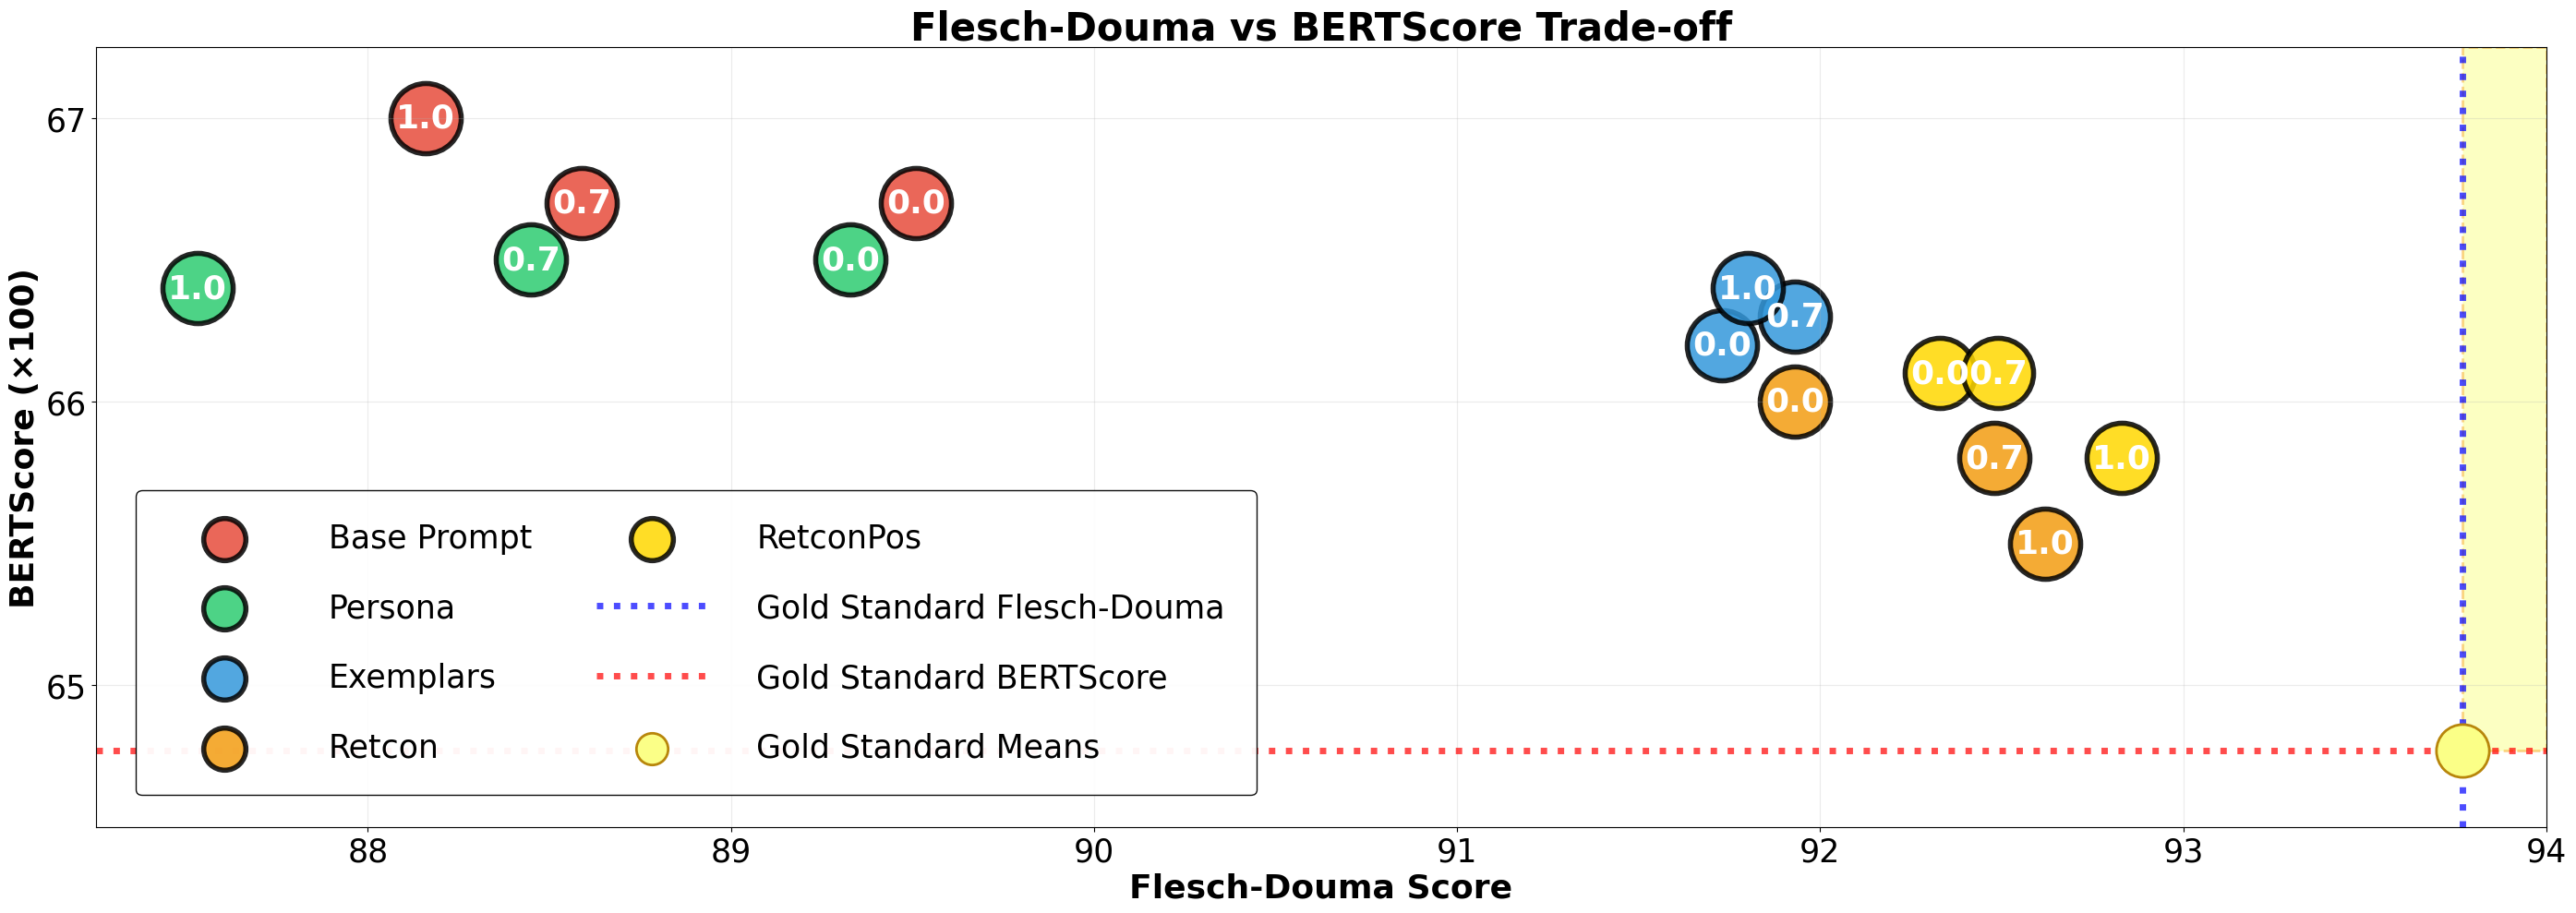

In [39]:
df_plot = df.copy()
df_plot['BERTScore'] = df_plot['BERTScore'] * 100

fig, ax = plt.subplots(figsize=(28, 10))

from matplotlib.patches import Rectangle

gold_x = 93.77
gold_y = 64.77

x_min, x_max = 87.25, 94
y_min, y_max = 64.5, 67.25

rect_gold = Rectangle((gold_x, gold_y), 
                       x_max - gold_x,
                       y_max - gold_y,
                       facecolor='#fbff87',
                       alpha=0.5,
                       edgecolor='#f9a825',
                       linewidth=2,
                       linestyle='--',
                       zorder=0)
ax.add_patch(rect_gold)

for i, strategy in enumerate(strategies):
    subset = df_plot[df_plot['Strategy'] == strategy]
    
    scatter = ax.scatter(subset['Flesch-Douma'], subset['BERTScore'],
                        s=3000,
                        alpha=0.85,
                        edgecolors='black', 
                        linewidth=4,
                        label=strategy, 
                        color=strategy_colors[strategy])
    
    for _, row in subset.iterrows():
        ax.annotate(f"{row['Temp']}", 
                   (row['Flesch-Douma'], row['BERTScore']),
                   xytext=(0, 0),
                   textcoords='offset points',
                   fontsize=26,
                   fontweight='bold',
                   ha='center',
                   va='center',
                   color='white')

ax.axvline(x=93.77, color='blue', linestyle=':', linewidth=5, alpha=0.7, label='Gold Standard Flesch-Douma')
ax.axhline(y=64.77, color='red', linestyle=':', linewidth=5, alpha=0.7, label='Gold Standard BERTScore')

ax.scatter(93.77, 64.77, 
           s=1700,
           color='#fbff87',
           edgecolors='#b8860b',
           linewidth=2,
           zorder=10,
           label='Gold Standard Means')

ax.set_xlabel('Flesch-Douma Score', fontsize=26, fontweight='bold')
ax.set_ylabel('BERTScore (×100)', fontsize=26, fontweight='bold')
ax.set_title('Flesch-Douma vs BERTScore Trade-off', fontsize=30, fontweight='bold')

ax.set_ylim(64.5, 67.25)
ax.set_yticks([65, 66, 67])
ax.set_xlim(87.25, 94)

legend = ax.legend(loc='lower left',
                   fontsize=25,
                   framealpha=0.95, 
                   edgecolor='black',
                   handletextpad=1.5,
                   labelspacing=1.2,
                   borderpad=1.0,
                   handlelength=3.5,
                   markerscale=0.6,
                   ncol=2,
                   columnspacing=2.0,
                   bbox_to_anchor=(0.01, 0.02))

ax.grid(True, alpha=0.25)
ax.tick_params(axis='both', which='major', labelsize=25)

plt.tight_layout()
plt.show()